# RRT* — Baseline Planner

## What is RRT*?

RRT* (Rapidly-exploring Random Tree Star) is an **asymptotically optimal** sampling-based motion planning algorithm introduced by Karaman & Frazzoli (2011). It builds on the original RRT algorithm by adding two key steps — **parent selection** and **rewiring** — that together guarantee the path cost converges to the optimum as the number of samples grows.

## Algorithm Overview

At each iteration, RRT* does the following:

1. **Sample** a random configuration $q_\text{rand}$ from the free configuration space $\mathcal{Q}_\text{free}$ (with a small probability of sampling the goal directly — the *goal bias*)
2. **Find the nearest node** $q_\text{near}$ already in the tree
3. **Steer** from $q_\text{near}$ toward $q_\text{rand}$ by at most a fixed step size $\eta$, producing a candidate new node $q_\text{new}$
4. **Collision check** the edge $q_\text{near} \to q_\text{new}$; discard if it intersects an obstacle
5. **Choose the best parent**: within a shrinking ball of radius $r_n = \min\left(\gamma \sqrt{\frac{\log n}{n}},\ \eta\right)$ around $q_\text{new}$, find the node that minimises the total cost from the root:
$$c_\text{new} = \min_{q \in \mathcal{N}(q_\text{new},\ r_n)} \left[ c(q) + \|q_\text{new} - q\| \right]$$
6. **Add** $q_\text{new}$ to the tree with the chosen parent
7. **Rewire**: for each node $q'$ in the same ball, check if routing through $q_\text{new}$ reduces $q'$'s cost-to-root. If so, update $q'$'s parent to $q_\text{new}$

The rewire radius shrinks as $O\!\left(\sqrt{\log n / n}\right)$, which keeps the total computation per iteration bounded while still guaranteeing asymptotic optimality.

## What the Plot Shows

The test environment is a $[0,1]^2$ configuration space containing a **single vertical wall** (the gray rectangle) spanning from $y=0$ to $y=0.7$, with a narrow gap above it. The planner is given:

- **Start** (green circle): $[0.1,\ 0.5]$
- **Goal** (red star): $[0.9,\ 0.5]$

The blue path is the best solution found after 2000 iterations. Since the wall blocks the direct horizontal route, RRT* correctly discovers the detour over the top of the wall through the gap at $y > 0.7$, producing a path with cost $\approx 0.988$ — noticeably longer than the straight-line distance of $0.8$ due to the forced detour.

## Why This is Our Baseline

In our experiments, all three algorithms (RRT*, Informed RRT*, and Hybrid-RRT*) share the **same tree structure, parent selection, and rewiring logic**. The only difference between them is the **sampling distribution** used in Step 1. This ensures that any performance differences we measure are attributable solely to the sampling strategy, not to implementation differences.

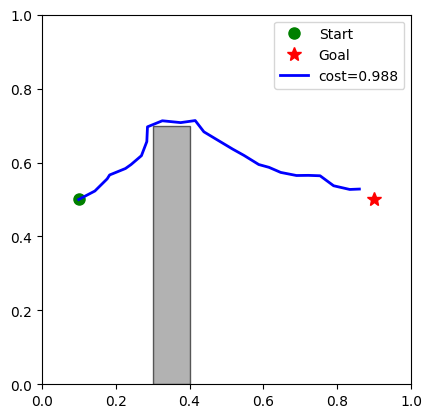

In [1]:
import matplotlib.pyplot as plt
from utils import Map, plot_map
from rrt_star import rrt_star

map_ = Map(x_lim=[0,1], y_lim=[0,1],
           obstacles=[[0.3, 0.0, 0.1, 0.7]])  # wall with gap at top

params = dict(max_iter=2000, step_size=0.05, gamma=1.0, goal_bias=0.05)

path, cost, t_init, n_init, cost_hist = rrt_star(
    map_, [0.1, 0.5], [0.9, 0.5], goal_radius=0.05, params=params)

fig, ax = plt.subplots()
plot_map(ax, map_, [0.1,0.5], [0.9,0.5])
if path is not None:
    ax.plot(path[:,0], path[:,1], 'b-', lw=2, label=f'cost={cost:.3f}')
ax.legend(); plt.show()